# Full CTRNN Training Pipeline
Train an ensemble of CTRNNs on the **Perceptual** and **Context** Mante-style (i.e., Mante et al. 2013) tasks. For each trained network we save its learning curve, scalar metrics, best-checkpoint weights, and test-set hidden activations.

PID computation and analysis are handled in notebook **06_PID_analysis.ipynb**.

### 0. Imports
Load PyTorch, the project's Mante-task data loader, and the CTRNN model. This notebook trains the 20 (10 perceptual, 10 context) CTRNNs for both tasks.

In [1]:
import torch                         # core PyTorch library
import torch.nn as nn                # base CTRNN model
import torch.nn.functional as F      # masked_cross_entropy loss
import numpy as np                   # stacking hidden activations for saving
import matplotlib.pyplot as plt      # learning curve figures
import copy                          # snapshot best-checkpoint weights during training
import os                            # file/folder management for saving models and metrics
import json                          # scalar metrics (loss/acc) per model
import time                          # wall-clock timing of epochs, training, and per-model runs

from src.tasks.data_loader import load_mante_data   # NeuroGym trial data -> DataLoader
from src.models.ctrnn import CTRNN                  # base continuous-time RNN (see README)

### Notebook parameters
Choose which task(s) to train and how many independently initialized CTRNNs (seeds) to run per task. These seeds are the sample the PID notebook later compares across, task by task.

In [2]:
# ---------------------------------------------------------------------------
# Top-of-notebook parameters
# ---------------------------------------------------------------------------
TASKS = ['perceptual', 'context']  # 'perceptual' = low integration demand, 'context' = high integration demand
N_p = 10  # number of independently seeded CTRNNs to train on the perceptual task
N_c = 10  # number of independently seeded CTRNNs to train on the context task

### Paths and data settings
Data paths, batch size, and output directories for this run. `SUBSAMPLE_STEP=10` compresses the raw dt=1ms trial data to an effective 10ms timestep (750 steps down to 75), keeping sequences short enough to train efficiently. `TEST_SPLIT_FMT` builds a *per-model* held-out split name: within a task the train and val sets are shared across all seeds, but each seeded CTRNN is tested on its own file (`test_01`, `test_02`, ...), later used to extract hidden activations for PID.

In [3]:
# Configuration (paths are relative to the notebooks/ directory, i.e. repo root via "..")
BASE_PATH = "../src/tasks/data/mante_style"
BATCH_SIZE = 1024 * 8
SUBSAMPLE_STEP = 1   # raw trials are dt=10ms; step=1 gives an effective 10ms timestep (750ms -> 75 steps)
# Each seeded CTRNN gets its own held-out test set (train/val are shared across seeds of a task).
# Seeds are numbered 1-based, so CTRNN_01 -> test_01, CTRNN_02 -> test_02, etc.
TEST_SPLIT_FMT = "test_{:02d}"  # per-model test split, formatted with the 1-based seed number

# Output directories (created per-task inside the training loop)
FIG_LC_DIR = "../figures/learning_curves"
RES_METRICS_DIR = "../results/accuracies_n_losses"
RES_WEIGHTS_DIR = "../results/model_weights"
RES_ACTS_DIR = "../results/model_activations"

### 1. The Architecture
We wrap the existing `CTRNN` so that the forward pass returns `(outputs, hidden_states)`, with shapes `(Batch, Time, Classes)` and `(Batch, Time, Hidden)` respectively. The CTRNN re-initialises its hidden state to zero at the start of every `forward` call. We need the hidden states because they, not the outputs, are what gets saved and fed into the PID analysis in the companion notebook.

In [4]:
class WrappedCTRNN(nn.Module):
    def __init__(self, input_dim, hidden_size, output_size=3):
        super().__init__()
        # Reuse the shared CTRNN (src/models/ctrnn.py) rather than redefining the dynamics here
        self.model = CTRNN(input_size=input_dim, hidden_size=hidden_size, output_size=output_size)
        
    def forward(self, x):
        # CTRNN expects (Batch, Seq, Dim).
        # return_dynamics=True also returns per-step predictions, used only by the
        # predictive-coding condition (trained elsewhere), so we drop them here.
        outputs, _, hidden_states = self.model(x, return_dynamics=True)
        return outputs, hidden_states   # hidden_states is what later gets saved for PID

### 2. Loss & Accuracy
The loss is cross-entropy over the decision-period timesteps only (periods == 2), flattened across batch x time (masked_cross_entropy), so every decision timestep of every trial contributes a term (multiple terms per trial). Accuracy uses the same decision-period mask: the proportion of decision-period timesteps whose argmax(output) matches the label, pooled across all timesteps (correct / total). Restricting to the decision period matches the task itself: the network only has to commit to a choice once fixation and stimulus presentation are done.

In [5]:
def masked_cross_entropy(outputs, labels, mask):
    """Cross-entropy over the decision-period timesteps only (mask, e.g. periods == 2),
    flattened across batch x time. Assumes mask is non-empty (guarded by the caller)."""
    # Only the decision period has a well-defined choice label; fixation and stimulus
    # timesteps are excluded so the network isn't penalized for not answering early.
    masked_outputs = outputs[mask]   # (n_decision_steps, n_classes)
    masked_labels = labels[mask]     # (n_decision_steps,)
    return F.cross_entropy(masked_outputs, masked_labels)


def masked_accuracy_counts(outputs, labels, mask):
    """Correct predictions and total count over the decision-period timesteps (mask).
    Return counts (not a proportion) so they can be pooled across batches."""
    preds = outputs[mask].argmax(dim=1)
    correct = (preds == labels[mask]).sum().item()
    total = int(mask.sum().item())
    return correct, total

### 3. Training, Testing & Plotting helpers
`train_ctrnn` trains a single network: it records train and validation loss/accuracy **once per epoch** (train loss = mean over batches, accuracy = pooled correct/total over decision-period timesteps), tracks the best checkpoint (lowest validation loss), and supports a toggleable early-stopping flag (`use_early_stopping`). It uses an Adam optimizer with a **`ReduceLROnPlateau` learning-rate schedule** driven by the validation loss (`scheduler.step(avg_val_loss)` each epoch): the LR is multiplied by `lr_factor` after `lr_patience` epochs without val-loss improvement, down to `lr_min`. The schedule *type* is the same for every network, but its plateau patience is set **per task** by the caller (see the training loop), and `lr_patience` is kept below the early-stopping `patience` so the LR can actually drop before training halts. Batches with no decision-period timesteps are skipped (`mask.sum() > 0` guard). On completion it restores the best weights into the model.

`test_ctrnn` runs the best checkpoint over the test set **one trial at a time**, zeroing the hidden state at the start of each trial; it computes test loss/accuracy with the same decision-period masking and collects the full hidden-state sequence per trial.

`plot_learning_curve` draws the two-panel learning-curve figure (loss and accuracy vs. epoch).

In [6]:
def train_ctrnn(model, train_loader, val_loader, device,
                num_epochs=50, lr=1e-3, patience=10, use_early_stopping=True,
                lr_factor=0.5, lr_patience=5, lr_min=1e-5):
    """
    Trains a single CTRNN:
    - Loss: cross-entropy over the decision-period timesteps only (periods == 2),
      flattened across batch x time (masked_cross_entropy).
    - LR schedule: ReduceLROnPlateau on validation loss (factor=lr_factor,
      patience=lr_patience, min_lr=lr_min). The schedule *type* is identical for every
      network; only its plateau patience varies by task (set by the caller). Keep
      lr_patience < patience (early stopping) so the LR gets a chance to drop before
      training is halted.
    - Logged once per epoch: train loss (mean over batches) and train accuracy
      (pooled correct/total over decision-period timesteps); likewise val loss/acc.
      Each logged epoch also reports its wall-clock duration in seconds and current LR.
    - Batches with no decision-period timesteps are skipped (mask.sum() > 0 guard).
    - Best checkpoint = lowest validation loss; restored into the model at the end.
    Returns (history, best_state).
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Reduce LR when validation loss stops improving. This adapts per-seed to each
    # network's own convergence, so no global epoch-budget tuning is needed.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=lr_factor, patience=lr_patience, min_lr=lr_min
    )

    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())  # fallback snapshot before any epoch runs
    patience_counter = 0

    # 'lr' logs the LR in effect during each epoch, for the learning-curve figure.
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    train_start = time.time()  # wall-clock start of the whole training run

    for epoch in range(num_epochs):
        epoch_start = time.time()  # wall-clock start of this epoch

        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        train_batches = 0
        train_correct, train_total = 0, 0

        for obs, labels, periods, cohs, ctxs in train_loader:
            obs = obs.to(device)
            labels = labels.to(device)
            periods = periods.to(device)
            # cohs (stimulus coherence) and ctxs (context cue) aren't needed to train the
            # network; they're only used later, alongside the saved activations, for PID.

            optimizer.zero_grad()
            outputs, _ = model(obs)          # (Batch, Time, Classes); hidden states unused while training

            mask = (periods == 2)            # decision-period timesteps only (see masked_cross_entropy)
            if mask.sum() > 0:
                loss = masked_cross_entropy(outputs, labels, mask)
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item()
                train_batches += 1
                c, t = masked_accuracy_counts(outputs, labels, mask)
                train_correct += c
                train_total += t

        avg_train_loss = running_train_loss / max(1, train_batches)
        train_acc = train_correct / max(1, train_total)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)

        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        val_batches = 0
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for obs, labels, periods, cohs, ctxs in val_loader:
                obs = obs.to(device)
                labels = labels.to(device)
                periods = periods.to(device)

                outputs, _ = model(obs)
                mask = (periods == 2)
                if mask.sum() > 0:
                    running_val_loss += masked_cross_entropy(outputs, labels, mask).item()
                    val_batches += 1
                    c, t = masked_accuracy_counts(outputs, labels, mask)
                    val_correct += c
                    val_total += t

        avg_val_loss = running_val_loss / max(1, val_batches)
        val_acc = val_correct / max(1, val_total)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        # --- LR SCHEDULE STEP (reduce on validation-loss plateau) ---
        scheduler.step(avg_val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # --- BEST-CHECKPOINT TRACKING (lowest val loss) ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        # Print progress every 5 epochs (and on the first epoch)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            epoch_time = time.time() - epoch_start  # this epoch's wall-clock duration
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch+1:03d}/{num_epochs}] | "
                  f"{epoch_time:.2f}s | "
                  f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.2e}")

        if use_early_stopping and patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}! Best Val Loss: {best_val_loss:.4f}")
            break

    total_train_time = time.time() - train_start  # wall-clock duration of the whole training run
    print(f"Training complete ({total_train_time:.2f}s). Restoring best model weights...")
    model.load_state_dict(best_state)  # use the best checkpoint, not necessarily the last epoch

    return history, best_state


def test_ctrnn(model, test_loader, device):
    """
    Runs the model over the test set one trial at a time (hidden state zeroed at the
    start of every trial). Loss/accuracy use the same decision-period masking as
    training (loss = mean over trials; accuracy = pooled correct/total). Returns:
      - hidden_activations: float32 array, shape [n_test_trials, T, n_hidden]
      - test_loss, test_acc
    """
    model.eval()
    hidden_list = []
    running_test_loss = 0.0
    test_batches = 0
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for obs, labels, periods, cohs, ctxs in test_loader:
            obs = obs.to(device)
            labels = labels.to(device)
            periods = periods.to(device)

            for i in range(obs.size(0)):
                # Process one trial at a time so each hidden-state trace comes from an
                # independent trial (a fresh forward call resets the hidden state to 0).
                # This matters for PID, which treats trials as i.i.d. samples.
                outputs, hidden = model(obs[i:i+1])   # (1, T, C), (1, T, H)

                mask = (periods[i:i+1] == 2)          # (1, T) decision-period timesteps
                if mask.sum() > 0:
                    li = labels[i:i+1]
                    running_test_loss += masked_cross_entropy(outputs, li, mask).item()
                    test_batches += 1
                    c, t = masked_accuracy_counts(outputs, li, mask)
                    test_correct += c
                    test_total += t

                hidden_list.append(hidden[0].cpu().numpy())   # (T, n_hidden), saved for PID

    hidden_activations = np.stack(hidden_list).astype(np.float32)  # [n_test_trials, T, n_hidden]
    test_loss = running_test_loss / max(1, test_batches)
    test_acc = test_correct / max(1, test_total)
    return hidden_activations, test_loss, test_acc


def plot_learning_curve(history, save_path):
    """Two stacked subplots: (1) train/val loss, (2) train/val accuracy, vs epoch."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax_loss, ax_acc) = plt.subplots(2, 1, figsize=(8, 8))

    ax_loss.plot(epochs, history['train_loss'], label='Train loss')
    ax_loss.plot(epochs, history['val_loss'], label='Val loss')
    ax_loss.set_xlabel('Epoch', fontsize=16)
    ax_loss.set_ylabel('Loss', fontsize=16)

    ax_acc.plot(epochs, history['train_acc'], label='Train acc')
    ax_acc.plot(epochs, history['val_acc'], label='Val acc')
    ax_acc.set_xlabel('Epoch', fontsize=16)
    ax_acc.set_ylabel('Accuracy', fontsize=16)

    for ax in (ax_loss, ax_acc):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=12)
        ax.legend(fontsize=14)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    plt.show()
    plt.close(fig)

### 4. Model dimensions and device
Both tasks share the same 7-channel input and 3-way output (fixate, choice 1, choice 2), so one architecture serves both tasks. Only the training data differs between the perceptual and context runs. Falls back to CPU if no GPU is available.

In [7]:
# Both tasks reuse the same 7-channel ContextDecisionMaking-v0 environment (src/tasks/README_data.md);
# the perceptual task just masks the second stimulus stream, so the architecture below is shared.
input_size = 7 
hidden_size = 100
output_size = 3    # Fixate, Choice 1, Choice 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device.type.upper()}")
if device.type == "cuda":
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")

Using compute device: CUDA
   GPU Name: NVIDIA GeForce GTX 1080


### 5. Train and save every seed, for every task
For each task, loop over the configured number of freshly initialized CTRNNs. Each one is trained, tested on the held-out split, and has its learning curve, scalar metrics, best checkpoint, and test-set hidden activations written to disk. These saved hidden activations are what the PID notebook consumes next.


TASK: PERCEPTUAL  (10 CTRNNs)

--- Training CTRNN on Perceptual Task | CTRNN_01 ---
Epoch [001/50] | 7.92s | Train Loss: 0.7387 | Val Loss: 0.6381 | Train Acc: 0.5463 | Val Acc: 0.7249 | LR: 1.00e-03
Epoch [005/50] | 7.23s | Train Loss: 0.2734 | Val Loss: 0.2765 | Train Acc: 0.8798 | Val Acc: 0.8780 | LR: 1.00e-03
Epoch [010/50] | 7.33s | Train Loss: 0.2688 | Val Loss: 0.2686 | Train Acc: 0.8806 | Val Acc: 0.8795 | LR: 1.00e-03
Epoch [015/50] | 7.28s | Train Loss: 0.2677 | Val Loss: 0.2653 | Train Acc: 0.8811 | Val Acc: 0.8821 | LR: 1.00e-03
Epoch [020/50] | 7.30s | Train Loss: 0.2609 | Val Loss: 0.2643 | Train Acc: 0.8835 | Val Acc: 0.8826 | LR: 5.00e-04
Epoch [025/50] | 7.32s | Train Loss: 0.2597 | Val Loss: 0.2634 | Train Acc: 0.8838 | Val Acc: 0.8830 | LR: 5.00e-04
Epoch [030/50] | 7.22s | Train Loss: 0.2584 | Val Loss: 0.2649 | Train Acc: 0.8843 | Val Acc: 0.8829 | LR: 5.00e-04
Epoch [035/50] | 7.19s | Train Loss: 0.2579 | Val Loss: 0.2621 | Train Acc: 0.8843 | Val Acc: 0.8819 | 

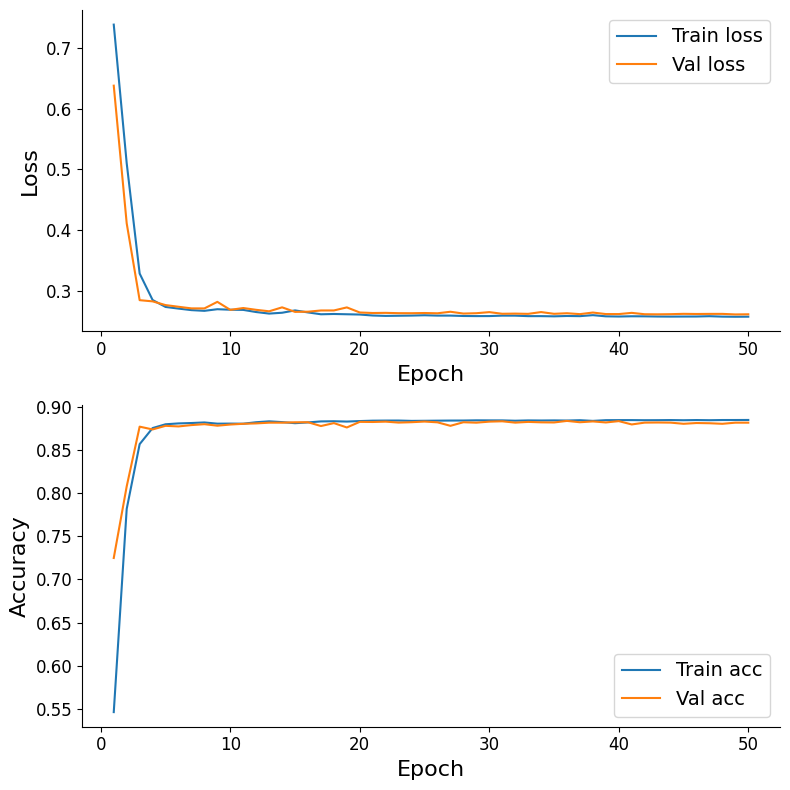

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_01.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_01.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_01.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_01.npy
Total model time: 447.27s
  train_loss=0.2574 | val_loss=0.2613 | test_loss=0.2684
  train_acc =0.8848 | val_acc =0.8817 | test_acc =0.8802

--- Training CTRNN on Perceptual Task | CTRNN_02 ---
Epoch [001/50] | 7.34s | Train Loss: 0.6029 | Val Loss: 0.4622 | Train Acc: 0.7230 | Val Acc: 0.7779 | LR: 1.00e-03
Epoch [005/50] | 7.19s | Train Loss: 0.2755 | Val Loss: 0.2776 | Train Acc: 0.8784 | Val Acc: 0.8787 | LR: 1.00e-03
Epoch [010/50] | 7.18s | Train Loss: 0.2684 | Val Loss: 0.2704 | Train Acc: 0.8807 | Val Acc: 0.8761 | LR: 1.00e-03
Epoch [015/50] | 7.11s | Train Loss: 0.2680 | Val Loss: 0.2764 | Train Acc: 0.8805 | Val Acc: 0.8784 | LR: 1.00e-03
Epoch [020/50] | 7.27s | Train Loss: 0.261

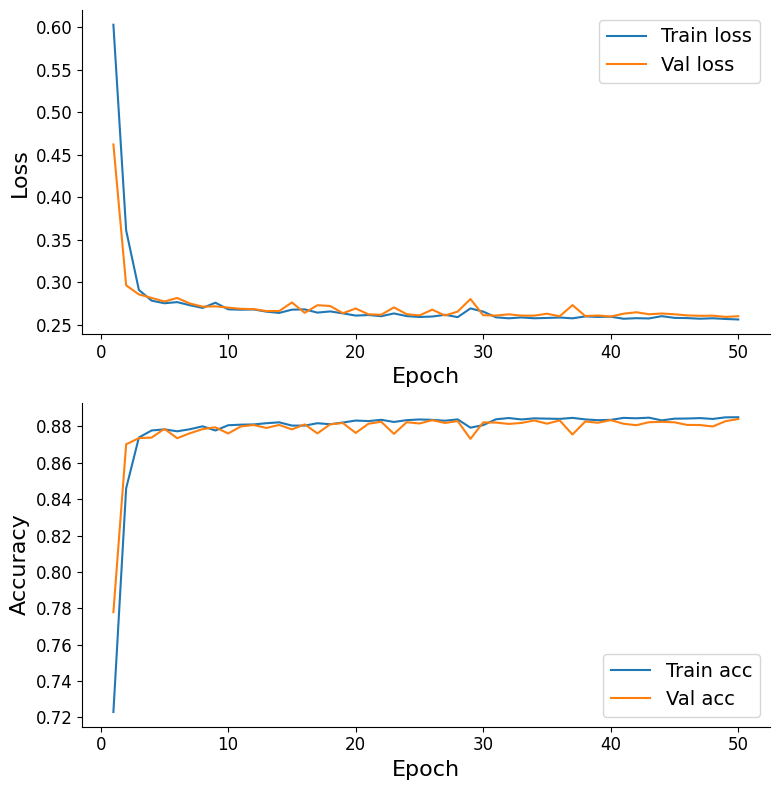

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_02.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_02.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_02.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_02.npy
Total model time: 438.72s
  train_loss=0.2564 | val_loss=0.2603 | test_loss=0.2539
  train_acc =0.8851 | val_acc =0.8841 | test_acc =0.8904

--- Training CTRNN on Perceptual Task | CTRNN_03 ---
Epoch [001/50] | 7.31s | Train Loss: 0.7088 | Val Loss: 0.6102 | Train Acc: 0.6372 | Val Acc: 0.8390 | LR: 1.00e-03
Epoch [005/50] | 7.11s | Train Loss: 0.2806 | Val Loss: 0.2797 | Train Acc: 0.8766 | Val Acc: 0.8761 | LR: 1.00e-03
Epoch [010/50] | 7.19s | Train Loss: 0.2840 | Val Loss: 0.2809 | Train Acc: 0.8744 | Val Acc: 0.8726 | LR: 1.00e-03
Epoch [015/50] | 7.18s | Train Loss: 0.2614 | Val Loss: 0.2651 | Train Acc: 0.8835 | Val Acc: 0.8798 | LR: 5.00e-04
Epoch [020/50] | 7.14s | Train Loss: 0.261

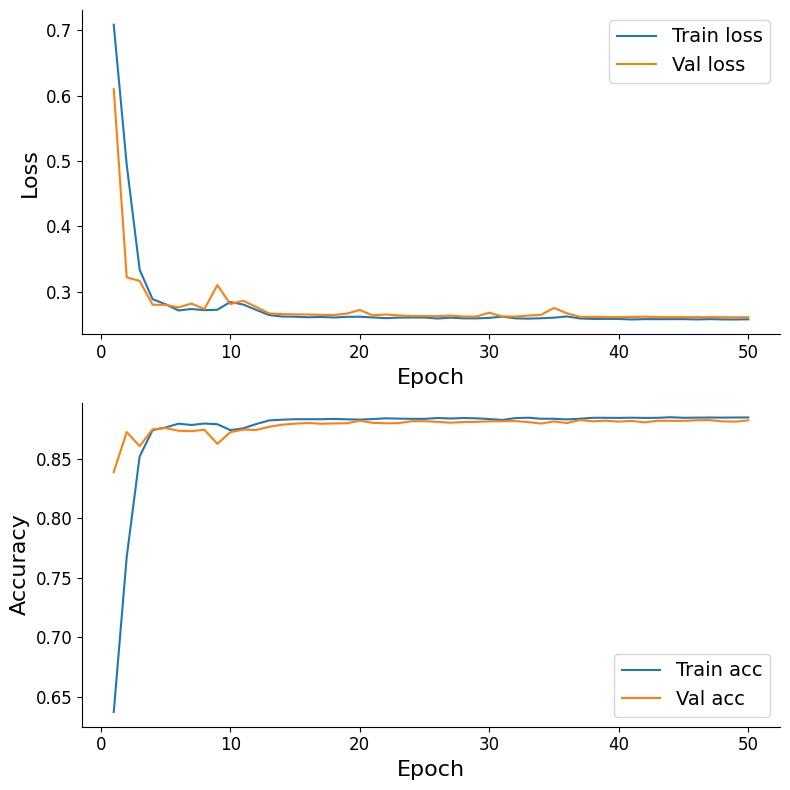

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_03.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_03.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_03.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_03.npy
Total model time: 439.37s
  train_loss=0.2575 | val_loss=0.2607 | test_loss=0.2513
  train_acc =0.8850 | val_acc =0.8825 | test_acc =0.8922

--- Training CTRNN on Perceptual Task | CTRNN_04 ---
Epoch [001/50] | 7.29s | Train Loss: 0.6613 | Val Loss: 0.3705 | Train Acc: 0.6885 | Val Acc: 0.8529 | LR: 1.00e-03
Epoch [005/50] | 7.17s | Train Loss: 0.2709 | Val Loss: 0.2801 | Train Acc: 0.8811 | Val Acc: 0.8761 | LR: 1.00e-03
Epoch [010/50] | 7.13s | Train Loss: 0.2658 | Val Loss: 0.2668 | Train Acc: 0.8818 | Val Acc: 0.8811 | LR: 1.00e-03
Epoch [015/50] | 7.17s | Train Loss: 0.2631 | Val Loss: 0.2646 | Train Acc: 0.8827 | Val Acc: 0.8806 | LR: 1.00e-03
Epoch [020/50] | 7.19s | Train Loss: 0.262

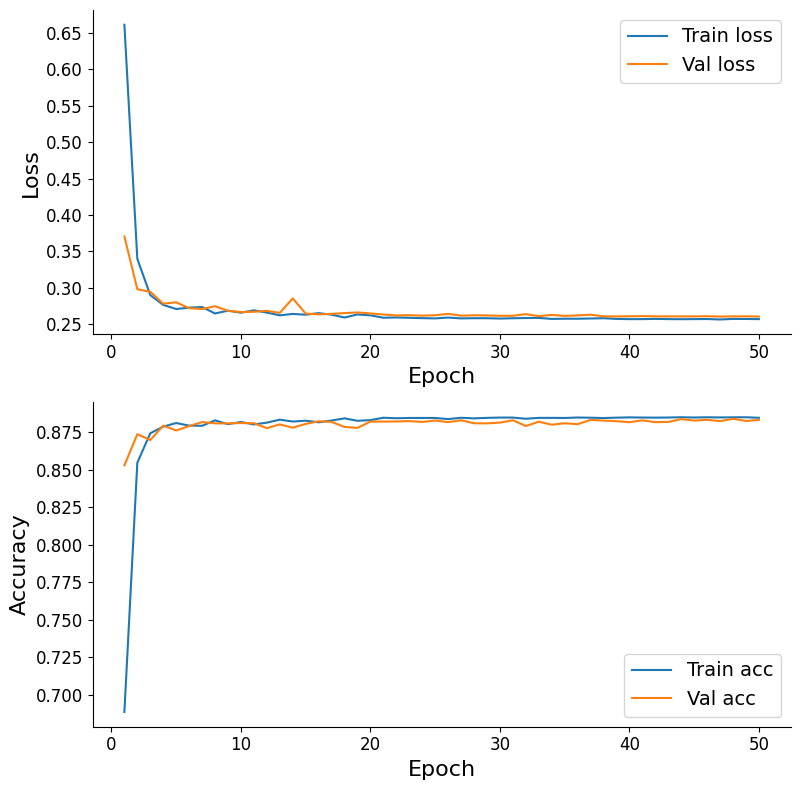

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_04.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_04.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_04.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_04.npy
Total model time: 447.50s
  train_loss=0.2570 | val_loss=0.2605 | test_loss=0.2538
  train_acc =0.8846 | val_acc =0.8832 | test_acc =0.8891

--- Training CTRNN on Perceptual Task | CTRNN_05 ---
Epoch [001/50] | 7.64s | Train Loss: 0.6271 | Val Loss: 0.4675 | Train Acc: 0.7084 | Val Acc: 0.7702 | LR: 1.00e-03
Epoch [005/50] | 7.53s | Train Loss: 0.2778 | Val Loss: 0.2831 | Train Acc: 0.8782 | Val Acc: 0.8736 | LR: 1.00e-03
Epoch [010/50] | 7.13s | Train Loss: 0.2698 | Val Loss: 0.2697 | Train Acc: 0.8802 | Val Acc: 0.8786 | LR: 1.00e-03
Epoch [015/50] | 7.07s | Train Loss: 0.2674 | Val Loss: 0.2666 | Train Acc: 0.8807 | Val Acc: 0.8804 | LR: 1.00e-03
Epoch [020/50] | 7.08s | Train Loss: 0.264

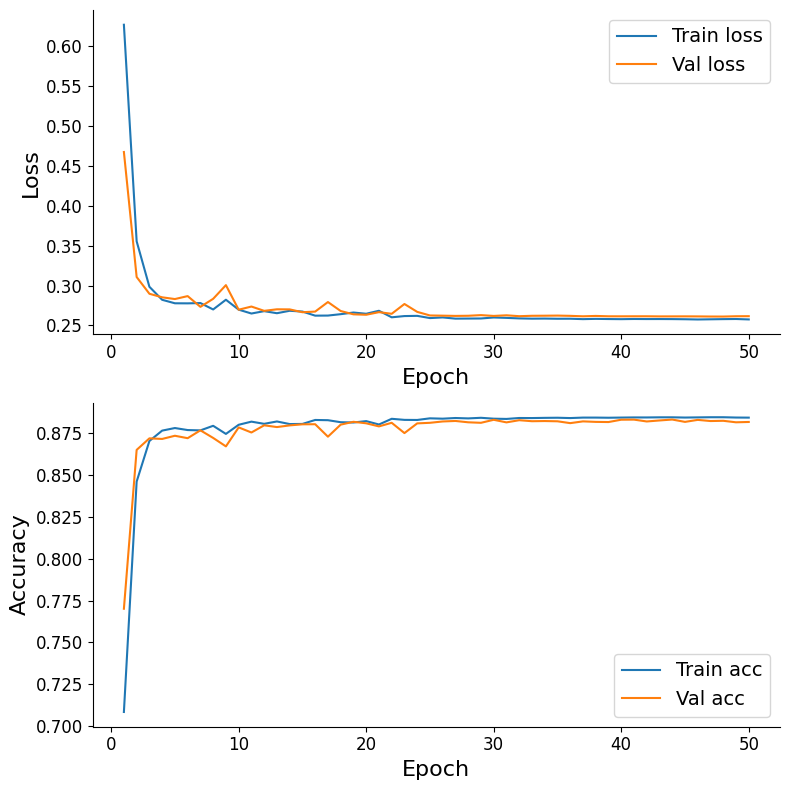

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_05.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_05.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_05.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_05.npy
Total model time: 435.36s
  train_loss=0.2575 | val_loss=0.2616 | test_loss=0.2403
  train_acc =0.8844 | val_acc =0.8819 | test_acc =0.8940

--- Training CTRNN on Perceptual Task | CTRNN_06 ---
Epoch [001/50] | 7.06s | Train Loss: 0.7254 | Val Loss: 0.6732 | Train Acc: 0.5477 | Val Acc: 0.5315 | LR: 1.00e-03
Epoch [005/50] | 7.10s | Train Loss: 0.2852 | Val Loss: 0.2787 | Train Acc: 0.8766 | Val Acc: 0.8746 | LR: 1.00e-03
Epoch [010/50] | 7.09s | Train Loss: 0.2730 | Val Loss: 0.2822 | Train Acc: 0.8798 | Val Acc: 0.8780 | LR: 1.00e-03
Epoch [015/50] | 7.09s | Train Loss: 0.2622 | Val Loss: 0.2702 | Train Acc: 0.8833 | Val Acc: 0.8806 | LR: 1.00e-03
Epoch [020/50] | 7.09s | Train Loss: 0.265

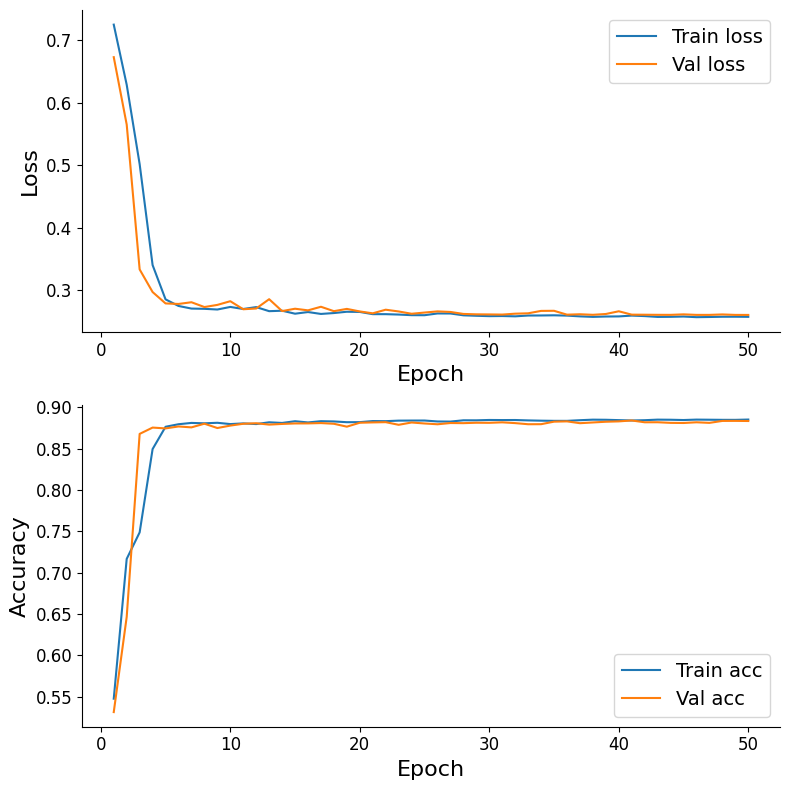

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_06.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_06.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_06.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_06.npy
Total model time: 429.77s
  train_loss=0.2572 | val_loss=0.2602 | test_loss=0.2704
  train_acc =0.8853 | val_acc =0.8835 | test_acc =0.8803

--- Training CTRNN on Perceptual Task | CTRNN_07 ---
Epoch [001/50] | 7.29s | Train Loss: 0.7149 | Val Loss: 0.6623 | Train Acc: 0.5353 | Val Acc: 0.6879 | LR: 1.00e-03
Epoch [005/50] | 7.17s | Train Loss: 0.2841 | Val Loss: 0.2844 | Train Acc: 0.8764 | Val Acc: 0.8759 | LR: 1.00e-03
Epoch [010/50] | 6.96s | Train Loss: 0.2705 | Val Loss: 0.2711 | Train Acc: 0.8804 | Val Acc: 0.8786 | LR: 1.00e-03
Epoch [015/50] | 7.14s | Train Loss: 0.2759 | Val Loss: 0.2686 | Train Acc: 0.8769 | Val Acc: 0.8783 | LR: 1.00e-03
Epoch [020/50] | 7.10s | Train Loss: 0.267

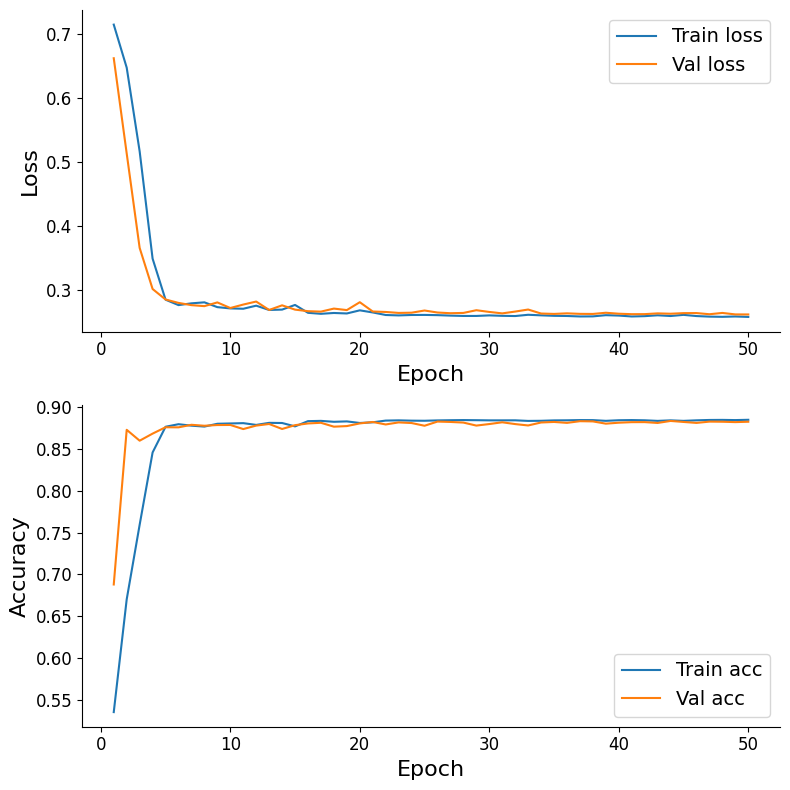

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_07.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_07.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_07.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_07.npy
Total model time: 434.07s
  train_loss=0.2571 | val_loss=0.2610 | test_loss=0.2555
  train_acc =0.8848 | val_acc =0.8824 | test_acc =0.8860

--- Training CTRNN on Perceptual Task | CTRNN_08 ---
Epoch [001/50] | 7.37s | Train Loss: 0.7176 | Val Loss: 0.6143 | Train Acc: 0.5485 | Val Acc: 0.8164 | LR: 1.00e-03
Epoch [005/50] | 7.11s | Train Loss: 0.2922 | Val Loss: 0.2901 | Train Acc: 0.8744 | Val Acc: 0.8726 | LR: 1.00e-03
Epoch [010/50] | 7.12s | Train Loss: 0.2684 | Val Loss: 0.2739 | Train Acc: 0.8817 | Val Acc: 0.8799 | LR: 1.00e-03
Epoch [015/50] | 7.08s | Train Loss: 0.2638 | Val Loss: 0.2674 | Train Acc: 0.8824 | Val Acc: 0.8793 | LR: 1.00e-03
Epoch [020/50] | 7.07s | Train Loss: 0.264

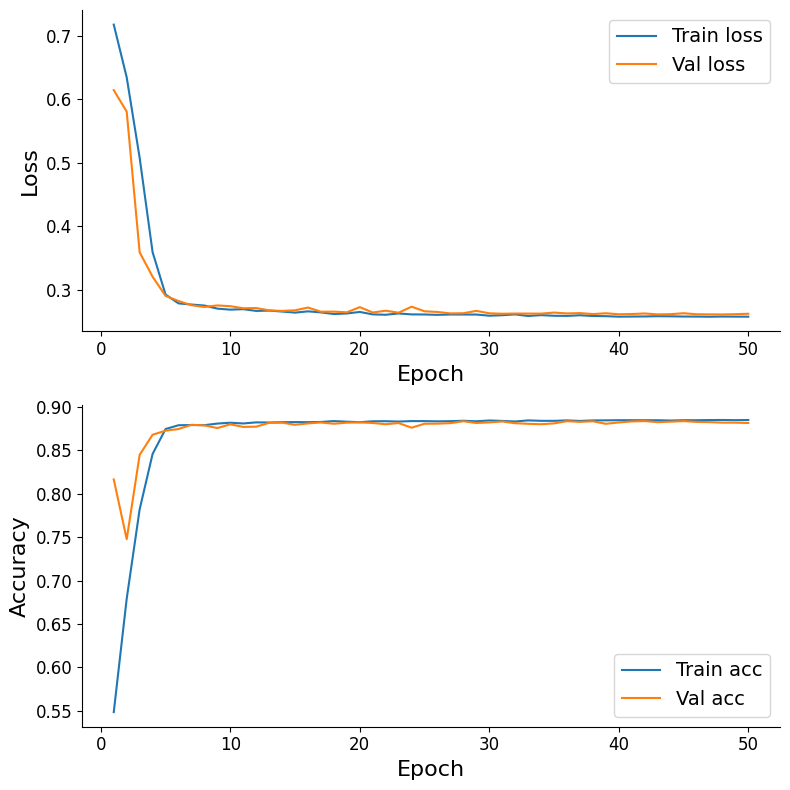

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_08.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_08.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_08.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_08.npy
Total model time: 434.72s
  train_loss=0.2573 | val_loss=0.2619 | test_loss=0.2557
  train_acc =0.8848 | val_acc =0.8813 | test_acc =0.8869

--- Training CTRNN on Perceptual Task | CTRNN_09 ---
Epoch [001/50] | 7.39s | Train Loss: 0.6855 | Val Loss: 0.3906 | Train Acc: 0.7179 | Val Acc: 0.8636 | LR: 1.00e-03
Epoch [005/50] | 6.99s | Train Loss: 0.2695 | Val Loss: 0.2716 | Train Acc: 0.8813 | Val Acc: 0.8809 | LR: 1.00e-03
Epoch [010/50] | 7.15s | Train Loss: 0.2656 | Val Loss: 0.2686 | Train Acc: 0.8815 | Val Acc: 0.8784 | LR: 1.00e-03
Epoch [015/50] | 7.06s | Train Loss: 0.2607 | Val Loss: 0.2640 | Train Acc: 0.8835 | Val Acc: 0.8818 | LR: 1.00e-03
Epoch [020/50] | 7.10s | Train Loss: 0.260

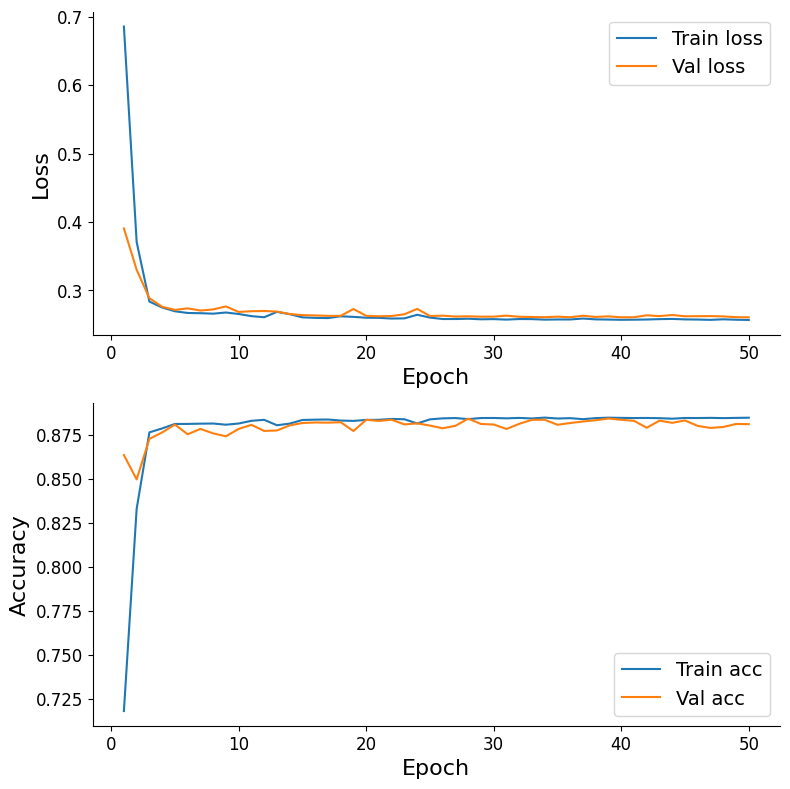

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_09.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_09.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_09.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_09.npy
Total model time: 431.23s
  train_loss=0.2568 | val_loss=0.2607 | test_loss=0.2609
  train_acc =0.8848 | val_acc =0.8811 | test_acc =0.8816

--- Training CTRNN on Perceptual Task | CTRNN_10 ---
Epoch [001/50] | 7.38s | Train Loss: 0.6966 | Val Loss: 0.5602 | Train Acc: 0.6067 | Val Acc: 0.8413 | LR: 1.00e-03
Epoch [005/50] | 7.12s | Train Loss: 0.2786 | Val Loss: 0.2826 | Train Acc: 0.8791 | Val Acc: 0.8737 | LR: 1.00e-03
Epoch [010/50] | 7.16s | Train Loss: 0.2725 | Val Loss: 0.2743 | Train Acc: 0.8799 | Val Acc: 0.8810 | LR: 1.00e-03
Epoch [015/50] | 7.11s | Train Loss: 0.2706 | Val Loss: 0.2711 | Train Acc: 0.8789 | Val Acc: 0.8763 | LR: 1.00e-03
Epoch [020/50] | 7.09s | Train Loss: 0.265

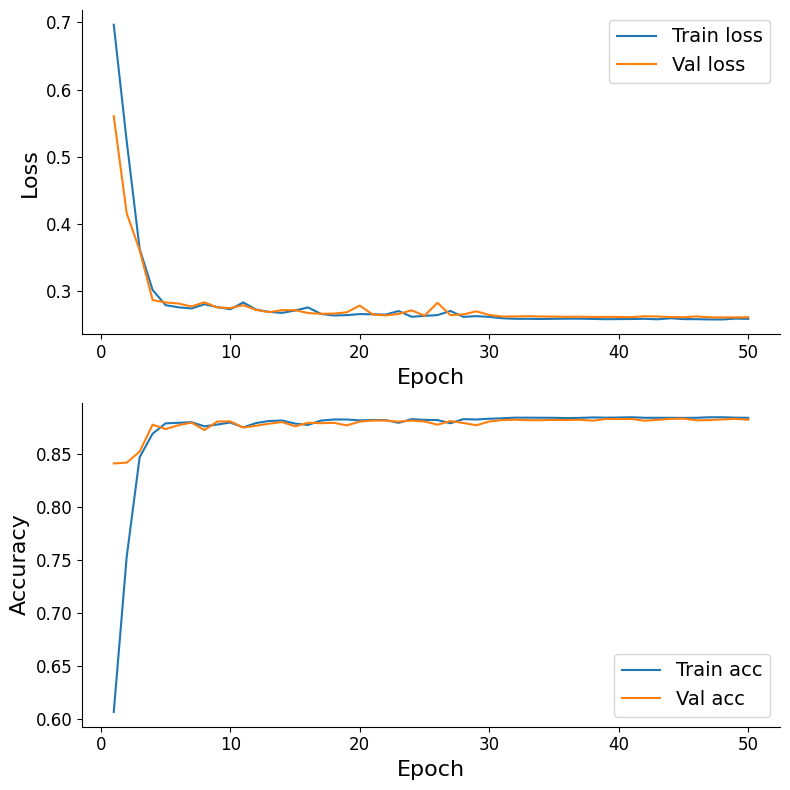

Saved learning curve to ../figures/learning_curves\perceptual\CTRNN_10.png
Saved metrics to ../results/accuracies_n_losses\perceptual\CTRNN_10.json
Saved model weights to ../results/model_weights\perceptual\CTRNN_10.pt
Saved hidden activations to ../results/model_activations\perceptual\CTRNN_10.npy
Total model time: 431.97s
  train_loss=0.2582 | val_loss=0.2606 | test_loss=0.2490
  train_acc =0.8843 | val_acc =0.8825 | test_acc =0.8900

TASK: CONTEXT  (10 CTRNNs)

--- Training CTRNN on Context Task | CTRNN_01 ---
Epoch [001/50] | 7.39s | Train Loss: 0.7155 | Val Loss: 0.6058 | Train Acc: 0.5903 | Val Acc: 0.7244 | LR: 1.00e-03
Epoch [005/50] | 7.17s | Train Loss: 0.3618 | Val Loss: 0.4099 | Train Acc: 0.8387 | Val Acc: 0.8065 | LR: 1.00e-03
Epoch [010/50] | 7.14s | Train Loss: 0.2911 | Val Loss: 0.3071 | Train Acc: 0.8716 | Val Acc: 0.8652 | LR: 1.00e-03
Epoch [015/50] | 7.16s | Train Loss: 0.2835 | Val Loss: 0.2795 | Train Acc: 0.8749 | Val Acc: 0.8746 | LR: 1.00e-03
Epoch [020/50] | 

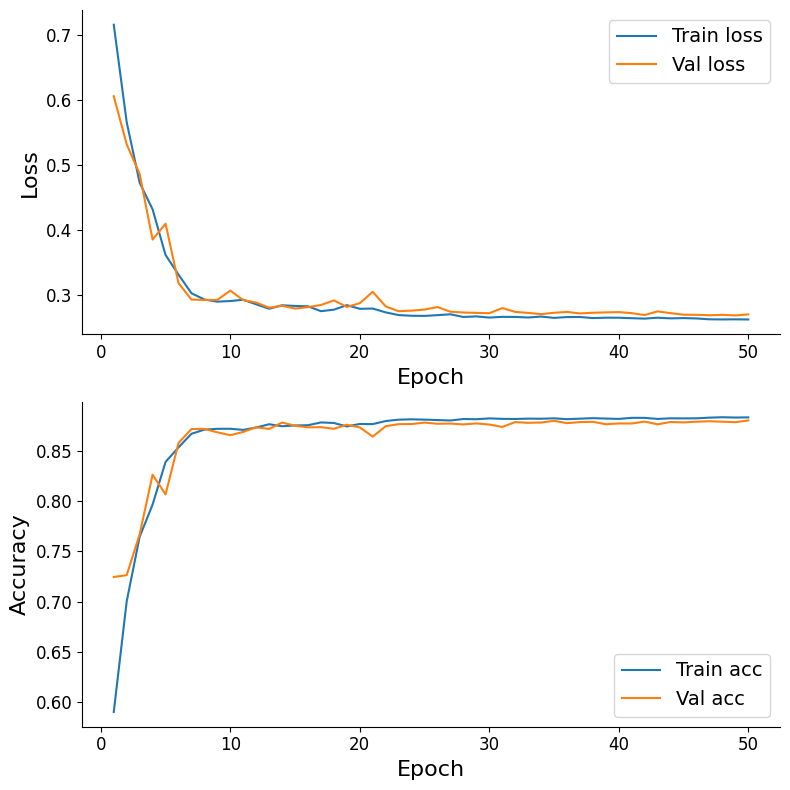

Saved learning curve to ../figures/learning_curves\context\CTRNN_01.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_01.json
Saved model weights to ../results/model_weights\context\CTRNN_01.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_01.npy
Total model time: 432.55s
  train_loss=0.2627 | val_loss=0.2705 | test_loss=0.2746
  train_acc =0.8829 | val_acc =0.8799 | test_acc =0.8783

--- Training CTRNN on Context Task | CTRNN_02 ---
Epoch [001/50] | 7.44s | Train Loss: 0.6853 | Val Loss: 0.5739 | Train Acc: 0.6659 | Val Acc: 0.6918 | LR: 1.00e-03
Epoch [005/50] | 7.11s | Train Loss: 0.3147 | Val Loss: 0.3074 | Train Acc: 0.8633 | Val Acc: 0.8659 | LR: 1.00e-03
Epoch [010/50] | 7.11s | Train Loss: 0.2808 | Val Loss: 0.2844 | Train Acc: 0.8759 | Val Acc: 0.8716 | LR: 1.00e-03
Epoch [015/50] | 7.19s | Train Loss: 0.2880 | Val Loss: 0.3082 | Train Acc: 0.8719 | Val Acc: 0.8663 | LR: 1.00e-03
Epoch [020/50] | 7.27s | Train Loss: 0.2725 | Val Loss: 0

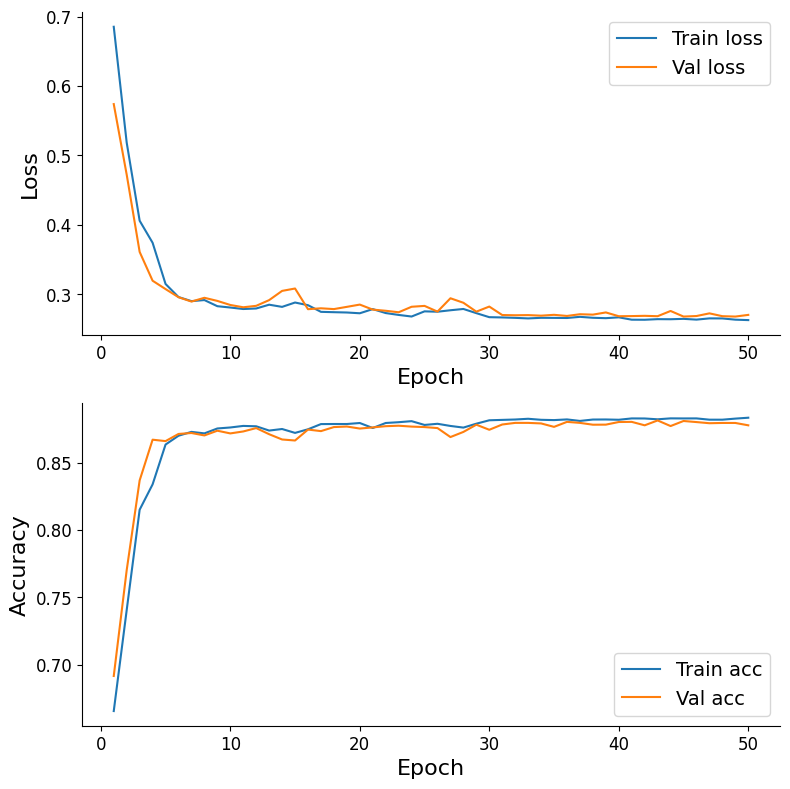

Saved learning curve to ../figures/learning_curves\context\CTRNN_02.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_02.json
Saved model weights to ../results/model_weights\context\CTRNN_02.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_02.npy
Total model time: 432.87s
  train_loss=0.2626 | val_loss=0.2702 | test_loss=0.2552
  train_acc =0.8832 | val_acc =0.8776 | test_acc =0.8909

--- Training CTRNN on Context Task | CTRNN_03 ---
Epoch [001/50] | 7.34s | Train Loss: 0.7224 | Val Loss: 0.6419 | Train Acc: 0.5464 | Val Acc: 0.7007 | LR: 1.00e-03
Epoch [005/50] | 7.20s | Train Loss: 0.3738 | Val Loss: 0.3358 | Train Acc: 0.8340 | Val Acc: 0.8549 | LR: 1.00e-03
Epoch [010/50] | 7.14s | Train Loss: 0.2813 | Val Loss: 0.2860 | Train Acc: 0.8760 | Val Acc: 0.8715 | LR: 1.00e-03
Epoch [015/50] | 7.25s | Train Loss: 0.2853 | Val Loss: 0.2869 | Train Acc: 0.8735 | Val Acc: 0.8736 | LR: 1.00e-03
Epoch [020/50] | 7.09s | Train Loss: 0.2714 | Val Loss: 0

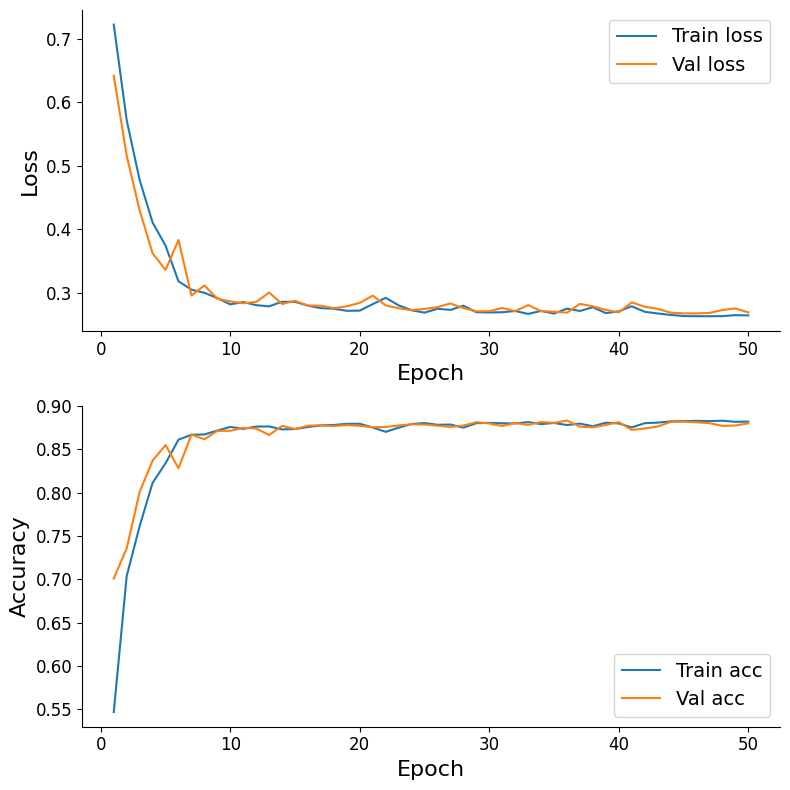

Saved learning curve to ../figures/learning_curves\context\CTRNN_03.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_03.json
Saved model weights to ../results/model_weights\context\CTRNN_03.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_03.npy
Total model time: 482.77s
  train_loss=0.2639 | val_loss=0.2687 | test_loss=0.2584
  train_acc =0.8822 | val_acc =0.8801 | test_acc =0.8921

--- Training CTRNN on Context Task | CTRNN_04 ---
Epoch [001/50] | 7.92s | Train Loss: 0.6980 | Val Loss: 0.5674 | Train Acc: 0.6155 | Val Acc: 0.7016 | LR: 1.00e-03
Epoch [005/50] | 7.89s | Train Loss: 0.3425 | Val Loss: 0.3409 | Train Acc: 0.8481 | Val Acc: 0.8558 | LR: 1.00e-03
Epoch [010/50] | 7.68s | Train Loss: 0.2797 | Val Loss: 0.2835 | Train Acc: 0.8765 | Val Acc: 0.8709 | LR: 1.00e-03
Epoch [015/50] | 8.38s | Train Loss: 0.2777 | Val Loss: 0.2952 | Train Acc: 0.8768 | Val Acc: 0.8674 | LR: 1.00e-03
Epoch [020/50] | 8.64s | Train Loss: 0.2844 | Val Loss: 0

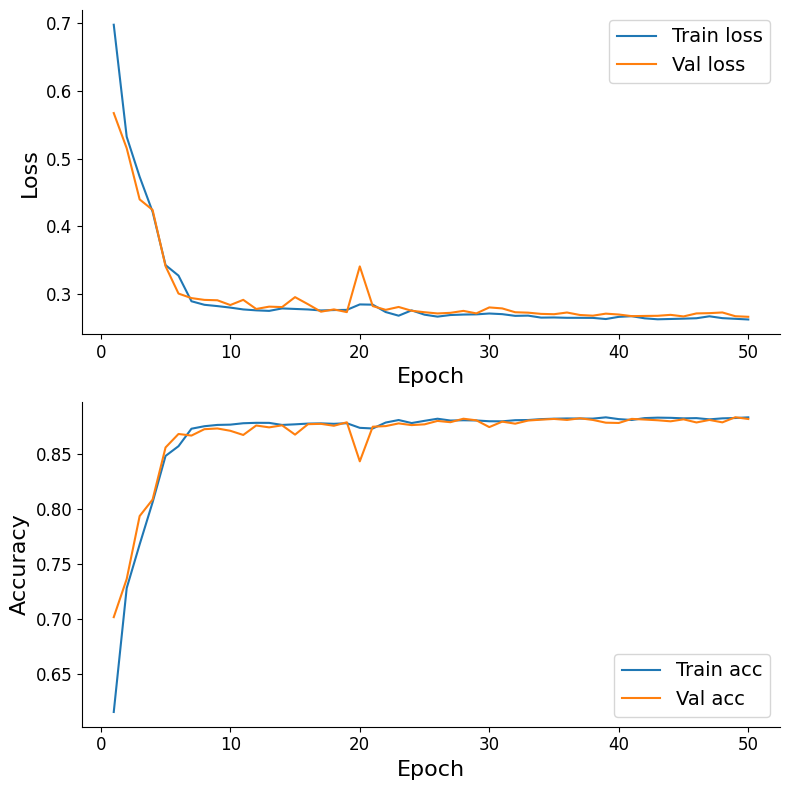

Saved learning curve to ../figures/learning_curves\context\CTRNN_04.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_04.json
Saved model weights to ../results/model_weights\context\CTRNN_04.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_04.npy
Total model time: 500.38s
  train_loss=0.2621 | val_loss=0.2661 | test_loss=0.2571
  train_acc =0.8831 | val_acc =0.8816 | test_acc =0.8886

--- Training CTRNN on Context Task | CTRNN_05 ---
Epoch [001/50] | 8.32s | Train Loss: 0.7348 | Val Loss: 0.6775 | Train Acc: 0.5513 | Val Acc: 0.5821 | LR: 1.00e-03
Epoch [005/50] | 7.73s | Train Loss: 0.3609 | Val Loss: 0.3236 | Train Acc: 0.8383 | Val Acc: 0.8566 | LR: 1.00e-03
Epoch [010/50] | 7.78s | Train Loss: 0.2843 | Val Loss: 0.2988 | Train Acc: 0.8747 | Val Acc: 0.8716 | LR: 1.00e-03
Epoch [015/50] | 8.34s | Train Loss: 0.2879 | Val Loss: 0.2866 | Train Acc: 0.8715 | Val Acc: 0.8730 | LR: 1.00e-03
Epoch [020/50] | 8.25s | Train Loss: 0.2693 | Val Loss: 0

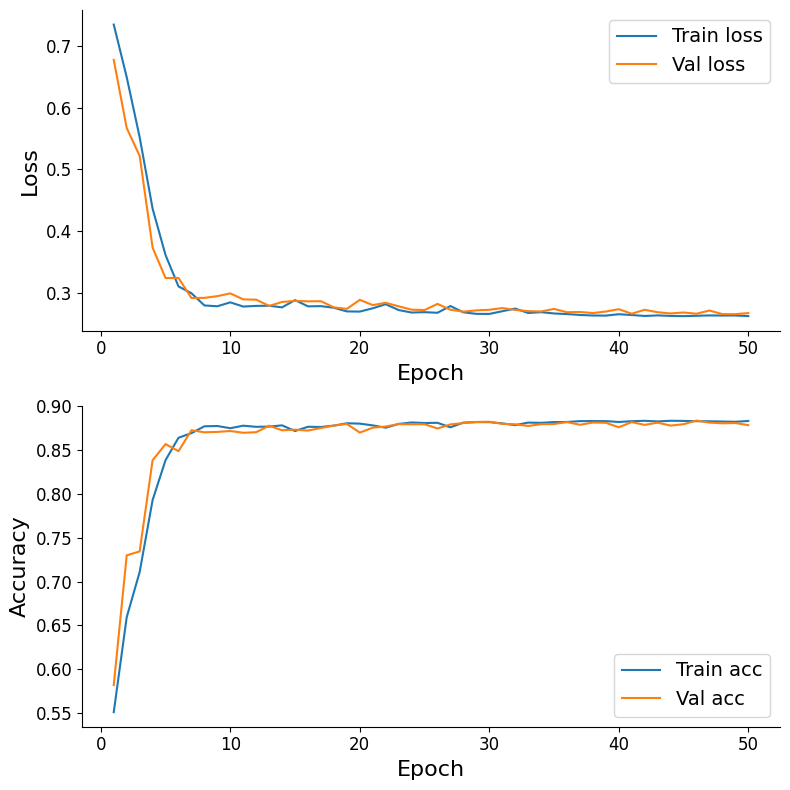

Saved learning curve to ../figures/learning_curves\context\CTRNN_05.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_05.json
Saved model weights to ../results/model_weights\context\CTRNN_05.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_05.npy
Total model time: 501.85s
  train_loss=0.2619 | val_loss=0.2668 | test_loss=0.2423
  train_acc =0.8830 | val_acc =0.8782 | test_acc =0.8911

--- Training CTRNN on Context Task | CTRNN_06 ---
Epoch [001/50] | 7.74s | Train Loss: 0.7129 | Val Loss: 0.6391 | Train Acc: 0.5693 | Val Acc: 0.6765 | LR: 1.00e-03
Epoch [005/50] | 8.46s | Train Loss: 0.3247 | Val Loss: 0.3033 | Train Acc: 0.8582 | Val Acc: 0.8699 | LR: 1.00e-03
Epoch [010/50] | 7.79s | Train Loss: 0.2935 | Val Loss: 0.2892 | Train Acc: 0.8702 | Val Acc: 0.8747 | LR: 1.00e-03
Epoch [015/50] | 8.37s | Train Loss: 0.2770 | Val Loss: 0.2797 | Train Acc: 0.8776 | Val Acc: 0.8780 | LR: 1.00e-03
Epoch [020/50] | 7.73s | Train Loss: 0.2765 | Val Loss: 0

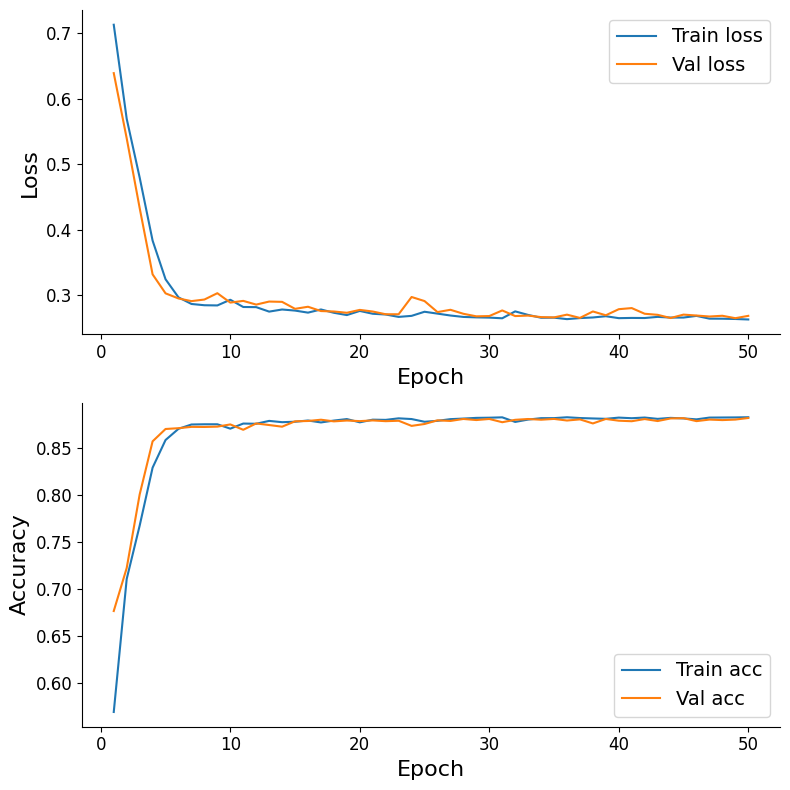

Saved learning curve to ../figures/learning_curves\context\CTRNN_06.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_06.json
Saved model weights to ../results/model_weights\context\CTRNN_06.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_06.npy
Total model time: 503.05s
  train_loss=0.2634 | val_loss=0.2690 | test_loss=0.2754
  train_acc =0.8823 | val_acc =0.8815 | test_acc =0.8791

--- Training CTRNN on Context Task | CTRNN_07 ---
Epoch [001/50] | 7.91s | Train Loss: 0.6773 | Val Loss: 0.6301 | Train Acc: 0.6156 | Val Acc: 0.6070 | LR: 1.00e-03
Epoch [005/50] | 8.32s | Train Loss: 0.3240 | Val Loss: 0.3015 | Train Acc: 0.8583 | Val Acc: 0.8687 | LR: 1.00e-03
Epoch [010/50] | 7.78s | Train Loss: 0.2805 | Val Loss: 0.3068 | Train Acc: 0.8759 | Val Acc: 0.8656 | LR: 1.00e-03
Epoch [015/50] | 7.57s | Train Loss: 0.2835 | Val Loss: 0.2893 | Train Acc: 0.8739 | Val Acc: 0.8767 | LR: 1.00e-03
Epoch [020/50] | 8.56s | Train Loss: 0.2686 | Val Loss: 0

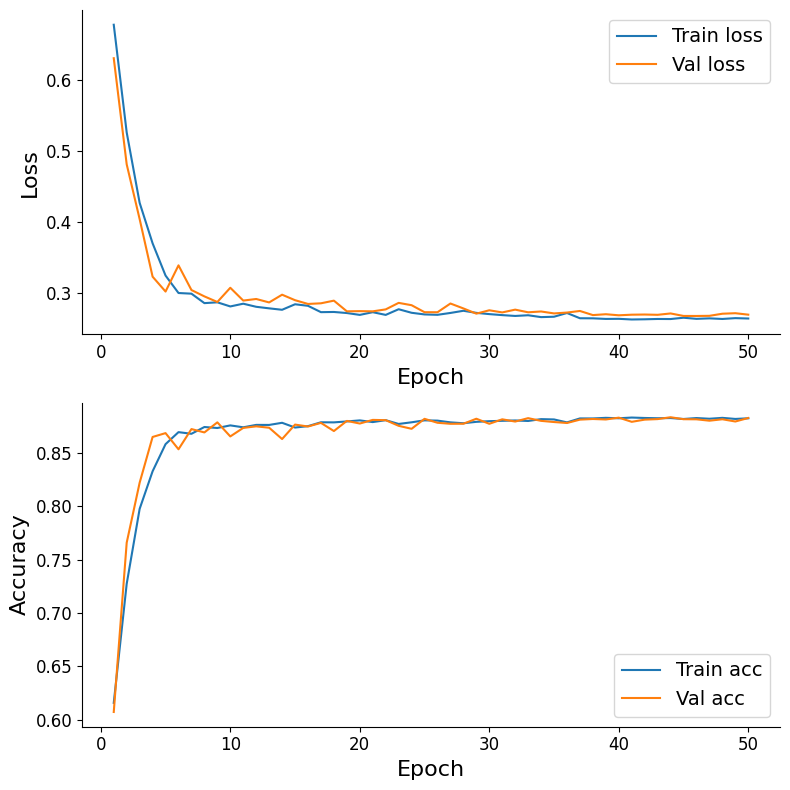

Saved learning curve to ../figures/learning_curves\context\CTRNN_07.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_07.json
Saved model weights to ../results/model_weights\context\CTRNN_07.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_07.npy
Total model time: 502.88s
  train_loss=0.2635 | val_loss=0.2689 | test_loss=0.2639
  train_acc =0.8826 | val_acc =0.8829 | test_acc =0.8800

--- Training CTRNN on Context Task | CTRNN_08 ---
Epoch [001/50] | 8.02s | Train Loss: 0.7443 | Val Loss: 0.6531 | Train Acc: 0.5550 | Val Acc: 0.6247 | LR: 1.00e-03
Epoch [005/50] | 7.82s | Train Loss: 0.3375 | Val Loss: 0.3269 | Train Acc: 0.8505 | Val Acc: 0.8555 | LR: 1.00e-03
Epoch [010/50] | 8.10s | Train Loss: 0.2814 | Val Loss: 0.2824 | Train Acc: 0.8754 | Val Acc: 0.8730 | LR: 1.00e-03
Epoch [015/50] | 7.87s | Train Loss: 0.2889 | Val Loss: 0.2969 | Train Acc: 0.8713 | Val Acc: 0.8722 | LR: 1.00e-03
Epoch [020/50] | 8.20s | Train Loss: 0.2769 | Val Loss: 0

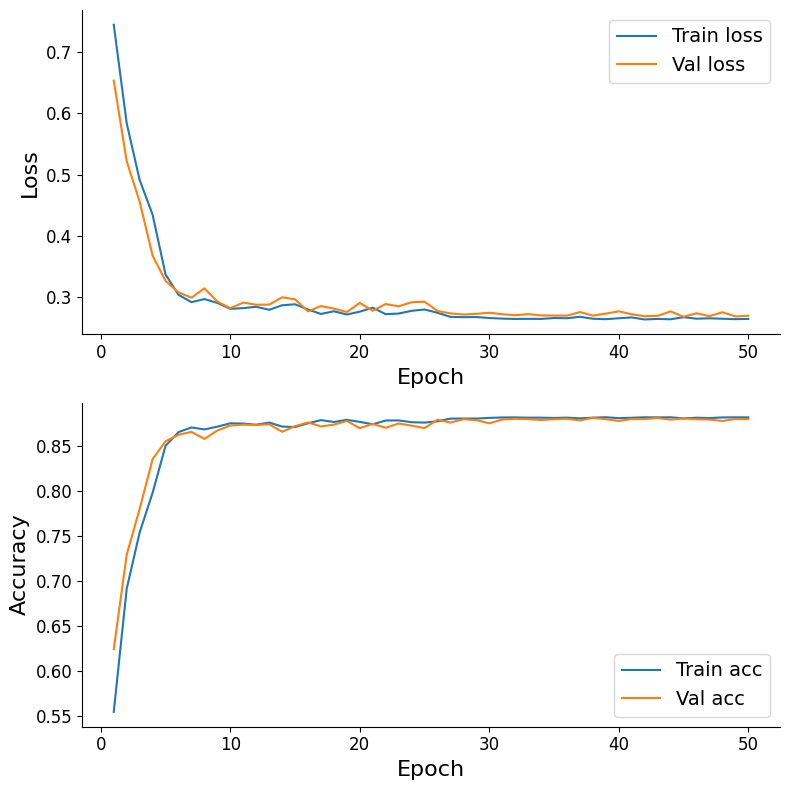

Saved learning curve to ../figures/learning_curves\context\CTRNN_08.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_08.json
Saved model weights to ../results/model_weights\context\CTRNN_08.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_08.npy
Total model time: 499.37s
  train_loss=0.2650 | val_loss=0.2701 | test_loss=0.2629
  train_acc =0.8820 | val_acc =0.8801 | test_acc =0.8841

--- Training CTRNN on Context Task | CTRNN_09 ---
Epoch [001/50] | 7.90s | Train Loss: 0.7127 | Val Loss: 0.6112 | Train Acc: 0.6046 | Val Acc: 0.6623 | LR: 1.00e-03
Epoch [005/50] | 8.42s | Train Loss: 0.3103 | Val Loss: 0.3216 | Train Acc: 0.8638 | Val Acc: 0.8612 | LR: 1.00e-03
Epoch [010/50] | 7.78s | Train Loss: 0.2935 | Val Loss: 0.2975 | Train Acc: 0.8702 | Val Acc: 0.8687 | LR: 1.00e-03
Epoch [015/50] | 8.23s | Train Loss: 0.2803 | Val Loss: 0.2822 | Train Acc: 0.8755 | Val Acc: 0.8743 | LR: 1.00e-03
Epoch [020/50] | 7.76s | Train Loss: 0.2754 | Val Loss: 0

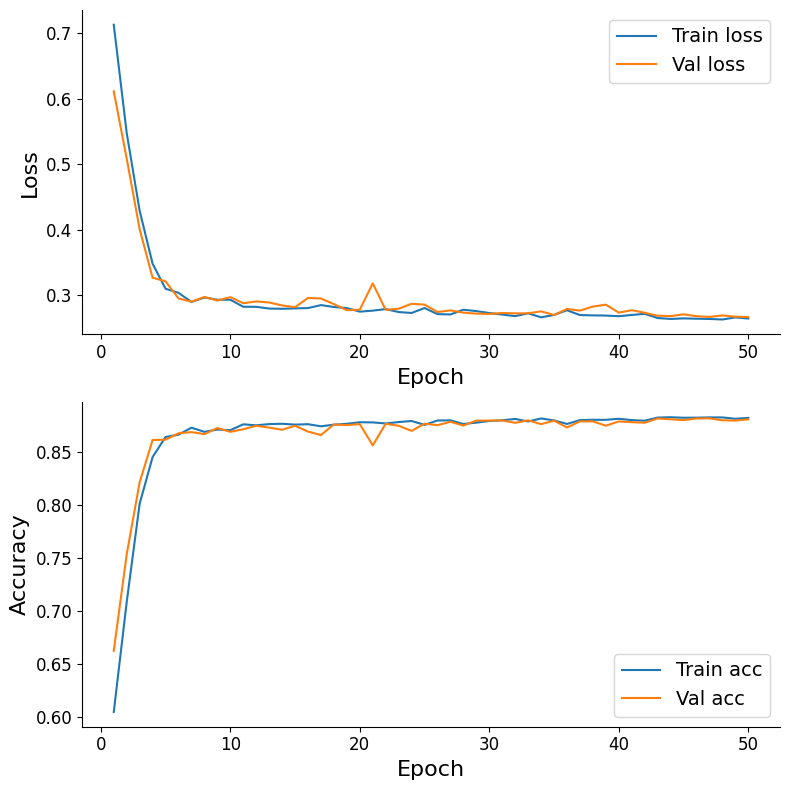

Saved learning curve to ../figures/learning_curves\context\CTRNN_09.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_09.json
Saved model weights to ../results/model_weights\context\CTRNN_09.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_09.npy
Total model time: 498.86s
  train_loss=0.2649 | val_loss=0.2671 | test_loss=0.2647
  train_acc =0.8818 | val_acc =0.8804 | test_acc =0.8819

--- Training CTRNN on Context Task | CTRNN_10 ---
Epoch [001/50] | 8.30s | Train Loss: 0.6760 | Val Loss: 0.5875 | Train Acc: 0.6392 | Val Acc: 0.6916 | LR: 1.00e-03
Epoch [005/50] | 8.05s | Train Loss: 0.3414 | Val Loss: 0.3104 | Train Acc: 0.8507 | Val Acc: 0.8662 | LR: 1.00e-03
Epoch [010/50] | 8.26s | Train Loss: 0.2922 | Val Loss: 0.2973 | Train Acc: 0.8714 | Val Acc: 0.8728 | LR: 1.00e-03
Epoch [015/50] | 7.91s | Train Loss: 0.2804 | Val Loss: 0.2927 | Train Acc: 0.8756 | Val Acc: 0.8752 | LR: 1.00e-03
Epoch [020/50] | 8.23s | Train Loss: 0.2840 | Val Loss: 0

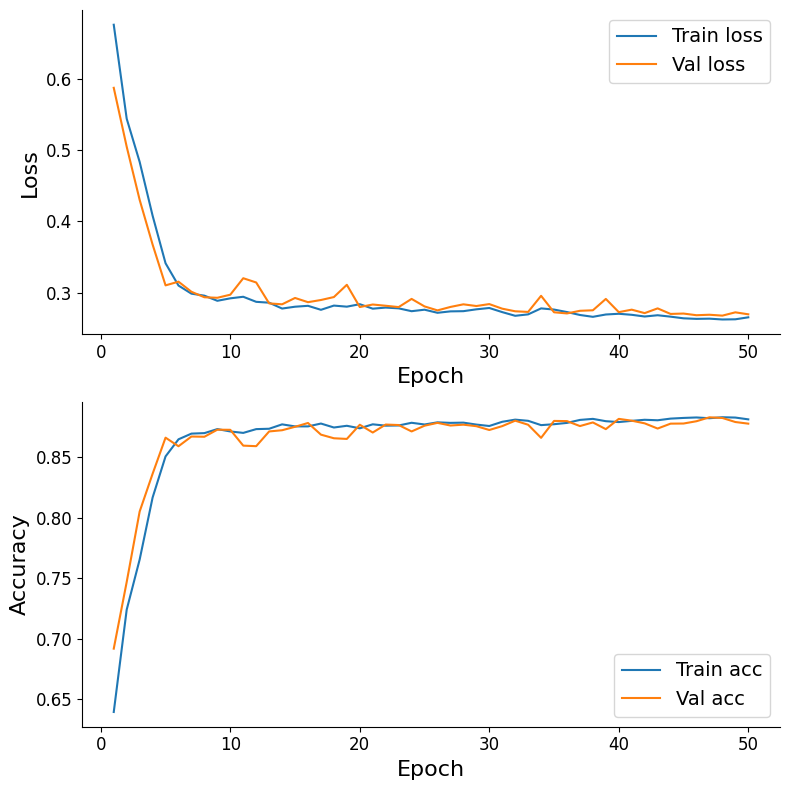

Saved learning curve to ../figures/learning_curves\context\CTRNN_10.png
Saved metrics to ../results/accuracies_n_losses\context\CTRNN_10.json
Saved model weights to ../results/model_weights\context\CTRNN_10.pt
Saved hidden activations to ../results/model_activations\context\CTRNN_10.npy
Total model time: 498.30s
  train_loss=0.2656 | val_loss=0.2698 | test_loss=0.2559
  train_acc =0.8814 | val_acc =0.8779 | test_acc =0.8888

Pipeline complete.


In [8]:
# Number of independently seeded CTRNNs to train per task (perceptual/context) is set at the top of the notebook.
N_MODELS = {'perceptual': N_p, 'context': N_c}
#N_MODELS = {'perceptual': 1, 'context': 1}

# Per-task LR schedule: the schedule TYPE (ReduceLROnPlateau on val loss) is identical for
# every RNN; only its plateau patience differs by task. The perceptual task has a low
# integration demand and converges cleanly, so it can cut the LR sooner (lr_patience=3);
# the context task is harder and its val loss is noisier, so it waits longer before cutting
# (lr_patience=6). Both stay below the early-stopping patience (10) so the LR actually gets a
# chance to drop before training halts.
LR_SCHED = {
    'perceptual': {'lr_factor': 0.5, 'lr_patience': 3, 'lr_min': 1e-5},
    'context':    {'lr_factor': 0.5, 'lr_patience': 6, 'lr_min': 1e-5},
}

# ------------------------------ Main Training Loop --------------------------------
for task in TASKS:
    n_models = N_MODELS[task]  # Number of independently seeded CTRNNs to train on this task
    print(f"\n{'='*70}\nTASK: {task.upper()}  ({n_models} CTRNNs)\n{'='*70}")

    # Create all output directories for this task
    for base in (FIG_LC_DIR, RES_METRICS_DIR, RES_WEIGHTS_DIR, RES_ACTS_DIR):
        os.makedirs(os.path.join(base, task), exist_ok=True)

    # Train/val loaders for this task are shared across every seed; only the held-out
    # test set differs per model (loaded inside the per-model loop below).
    train_loader = load_mante_data(f'{BASE_PATH}/{task}/train.npz', batch_size=BATCH_SIZE, shuffle=True,  subsample_step=SUBSAMPLE_STEP)
    val_loader   = load_mante_data(f'{BASE_PATH}/{task}/val.npz',   batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)

    # ------------------------------ Train, Evaluate, Test, and Save CTRNNs --------------------------------
    for idx in range(n_models):
        seed_num = idx + 1              # 1-based seed numbering used for names and test splits
        name = f"CTRNN_{seed_num:02d}"  # padded, 1-based: CTRNN_01, CTRNN_02, ...
        print(f"\n--- Training CTRNN on {task.capitalize()} Task | {name} ---")

        model_start = time.time()  # wall-clock start of this model's full train+test+save run

        # ---- Train/Evaluate ----
        # Each idx is an independent seed: fresh random init, fresh optimizer, same task data.
        # These seeds are exactly what the PID analysis aggregates over, per task.
        # LR_SCHED[task] applies the task-specific ReduceLROnPlateau settings (same for all seeds of the task).
        model = WrappedCTRNN(input_size, hidden_size, output_size).to(device)
        history, best_state = train_ctrnn(model, train_loader, val_loader, device,
                                          num_epochs=50, **LR_SCHED[task])

        # ---- Test ----
        # Each seed gets its own held-out split (CTRNN_01 -> test_01, CTRNN_02 -> test_02, ...),
        # whose hidden activations the PID notebook will read. Evaluate with the best
        # (lowest val-loss) checkpoint, not the last epoch's weights.
        test_split = TEST_SPLIT_FMT.format(seed_num)
        test_loader = load_mante_data(f'{BASE_PATH}/{task}/{test_split}.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)
        print(f"Using test split: {test_split}")
        hidden_activations, test_loss, test_acc = test_ctrnn(model, test_loader, device)

        # ---- Save ----
        # Scalar metrics: train/val from the last epoch, test from the test run
        metrics = {
            'train_loss': history['train_loss'][-1],
            'val_loss':   history['val_loss'][-1],
            'test_loss':  test_loss,
            'train_acc':  history['train_acc'][-1],
            'val_acc':    history['val_acc'][-1],
            'test_acc':   test_acc,
        }

        # Resolve output paths
        fig_path     = os.path.join(FIG_LC_DIR, task, f"{name}.png")
        metrics_path = os.path.join(RES_METRICS_DIR, task, f"{name}.json")
        weights_path = os.path.join(RES_WEIGHTS_DIR, task, f"{name}.pt")
        acts_path    = os.path.join(RES_ACTS_DIR, task, f"{name}.npy")

        # 1. Learning curve figure (saved + displayed inline): a quick sanity check that training converged
        plot_learning_curve(history, fig_path)
        print(f"Saved learning curve to {fig_path}")

        # 2. Scalar metrics JSON: used later to confirm accuracy is matched across conditions (README)
        with open(metrics_path, 'w') as f:
            json.dump(metrics, f, indent=2)
        print(f"Saved metrics to {metrics_path}")

        # 3. Best-checkpoint weights: kept so a model can be reloaded or re-evaluated without retraining
        torch.save(best_state, weights_path)
        print(f"Saved model weights to {weights_path}")

        # 4. Hidden activations [n_test_trials, T, n_hidden]: the actual input to the PID notebook
        np.save(acts_path, hidden_activations)
        print(f"Saved hidden activations to {acts_path}")

        total_model_time = time.time() - model_start  # full train+test+save wall-clock for this model
        print(f"Total model time: {total_model_time:.2f}s")
        print(f"  train_loss={metrics['train_loss']:.4f} | val_loss={metrics['val_loss']:.4f} | test_loss={metrics['test_loss']:.4f}")
        print(f"  train_acc ={metrics['train_acc']:.4f} | val_acc ={metrics['val_acc']:.4f} | test_acc ={metrics['test_acc']:.4f}")

print("\nPipeline complete.")